In [62]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [63]:
class BMIState(TypedDict):
    weight: float
    height: float
    bmi: float
    category: str

In [64]:
def calculate_bmi(state: BMIState) -> BMIState:
    bmi = state["weight"] / (state["height"] ** 2)
    state["bmi"] = round(bmi, 2)
    return state


In [65]:
def interpret_bmi(state: BMIState) -> BMIState:
    if state["bmi"] < 18.5:
        state["category"] = "Underweight"
    elif state["bmi"] < 25:
        state["category"] = "Normal weight"
    return state


In [66]:
# define graph
graph = StateGraph(BMIState)

In [67]:
# add nodes
graph.add_node("calculate_bmi", calculate_bmi)
graph.add_node("interpret_bmi", interpret_bmi)
# add edges
graph.add_edge(START, "calculate_bmi")
graph.add_edge("calculate_bmi", "interpret_bmi")
graph.add_edge("interpret_bmi", END)

workflow = graph.compile()


In [74]:
# execute the graph
initial_state = {"weight": 60, "height": 1.73}
output = workflow.invoke(initial_state)
print(output)

{'weight': 60, 'height': 1.73, 'bmi': 20.05, 'category': 'Normal weight'}


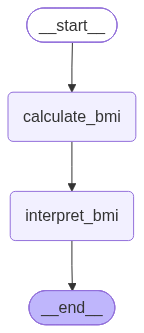

In [69]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())
